## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
df = pd.read_csv("./data/golub.csv")
y = df["cancer"].map({"allB": 0, "allT": 0, "aml": 1}).astype(float)
X = df.drop(columns=["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer"]) #looked at the dataset and saw that everything after this first 6 columns are the actual genes we want to work with.

. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

My MSE and all relevant outputs is in the below cell.


OLS training MSE: 6.765406708643482e-30


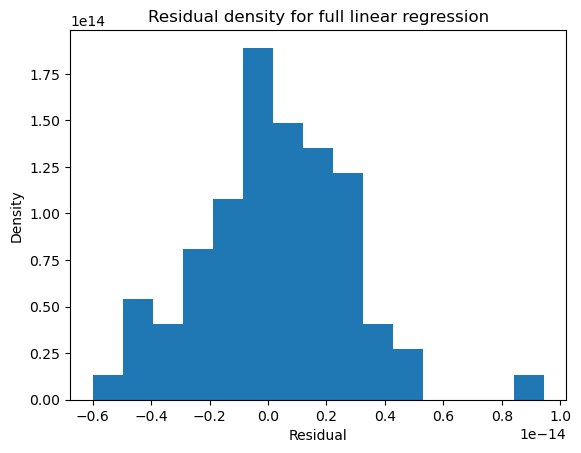

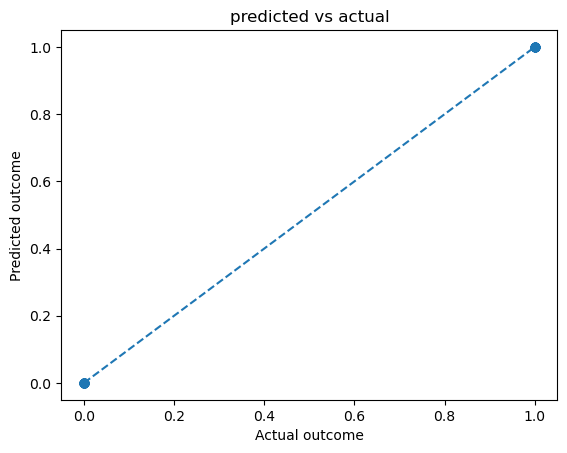

In [5]:
ols = LinearRegression()
ols.fit(X, y)
ols_pred = ols.predict(X)
ols_resid = y - ols_pred
ols_train_mse = mean_squared_error(y, ols_pred)
print("OLS training MSE:", ols_train_mse)

# residuals
plt.figure()
plt.hist(ols_resid, bins=15, density=True)
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Residual density for full linear regression")
plt.show()

# scatterplot
plt.figure()
plt.scatter(y, ols_pred)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Actual outcome")
plt.ylabel("Predicted outcome")
plt.title("predicted vs actual")
plt.show()


3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

The linear regression has an extremely low training error primarily because the number of genes is much bigger than the number of patients. This imbalance is what gives the model low bias on the training set, but it also means the fitted coefficients are unstable, as in small changes in the training fold can cause huge changes in the estimated regression surface (thus variance is high).

In [6]:
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)
ols_cv_mses = []
for train_idx, test_idx in kf10.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    fold_model = LinearRegression()
    fold_model.fit(X_train, y_train)
    fold_pred = fold_model.predict(X_test)
    ols_cv_mses.append(mean_squared_error(y_test, fold_pred))

print("10-fold cross validation MSEs:", ols_cv_mses)
print("Mean cross validation MSE:", np.mean(ols_cv_mses))
print("SD of cross validation MSE:", np.std(ols_cv_mses))

10-fold cross validation MSEs: [0.04596530020264303, 0.04231634130766301, 0.04823094042540569, 0.07943782573168401, 0.01576510815434635, 0.07586618007032674, 0.06668907812158185, 0.03873804419591487, 0.018779657496205495, 0.027870118087356264]
Mean cross validation MSE: 0.04596585937931273
SD of cross validation MSE: 0.021197111103131914



4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

The set of genes selected is the list that is printed after the `Number discarded` field, and the `Number discarded` field is the number of genes discarded from the model.

Number discarded: 7056
['AF000560_at', 'AF002020_at', 'D26579_at', 'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at', 'J04164_at', 'L13278_at', 'L20941_at', 'M12759_at', 'M17754_at', 'M19507_at', 'M19645_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27819_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at', 'U34877_at', 'U36621_cds2_at', 'U41816_at', 'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U77604_at', 'U82759_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X69111_at', 'X81479_at', 'X83378_at', 'X87838_at', 'X95735_at', 'X96698_at', 'Y07604_at', 'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'U37055_rna1_s_at', 'U59632_s_at', 'X07438_s_at', 'M13690_s_at', 'M26708_s_at', 'M84371_rna1_s_at', 'X12876_s_at', 'M75715_s_at', 'U26312_s_at', 'X85116_rna1_s_at',

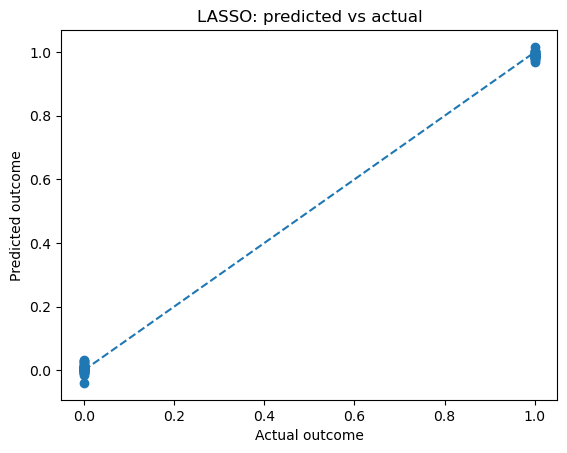

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
alpha_grid = np.logspace(-3, 0, 30)
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
lasso_cv = LassoCV(
    alphas=alpha_grid,
    cv=kf5,
    random_state=42,
    max_iter=5000,
    selection="random",
    n_jobs=-1
)
lasso_cv.fit(X_scaled, y)
lasso_pred = lasso_cv.predict(X_scaled)
lasso_train_mse = mean_squared_error(y, lasso_pred)
selected_genes = X.columns[lasso_cv.coef_ != 0]
print("Number discarded:", X.shape[1] - len(selected_genes))
print(selected_genes.tolist())

plt.figure()
plt.scatter(y, lasso_pred)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Actual outcome")
plt.ylabel("Predicted outcome")
plt.title("LASSO: predicted vs actual")
plt.show()


5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

The minimum cross-validated MSE is 0.043102, achieved at alpha = 0.003290. Large alpha values (around >= 0.1 )underfit because the penalty is too strong, while very small alpha values (around < 0.0033) begin to reduce the benefit of regularization and can lead to overfitting.

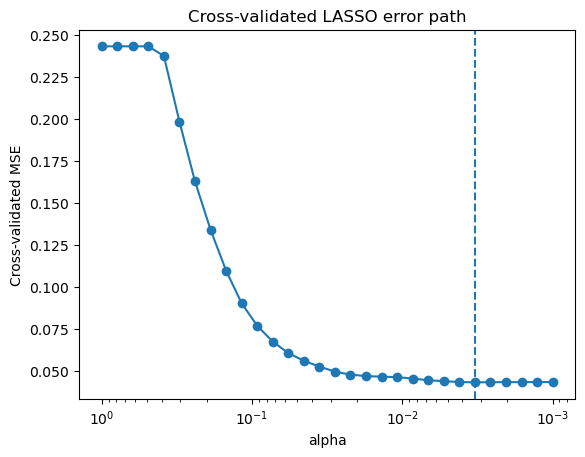

In [8]:
mean_cv_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure()
plt.semilogx(lasso_cv.alphas_, mean_cv_mse, marker="o")
plt.axvline(lasso_cv.alpha_, linestyle="--")
plt.gca().invert_xaxis()
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Cross-validated LASSO error path")
plt.show()
curve_df = pd.DataFrame({
    "alpha": lasso_cv.alphas_,
    "cv_mse": mean_cv_mse
}).sort_values("alpha", ascending=False)
# curve_df.head(10), curve_df.tail(10)


6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

The linear regression is with far more predictors than observations, allowing it to interpolate the training data almost exactly thus training error becomes nearly zero. But, this perfect fit mostly reflects things like noise-fitting and coefficient instability and not true signal recovery. LASSO shrinks many coefficients to zero using the L1 penalty, which introduces some bias but it very greatly lowers variance and usually improves unseen data prediction.


7. Why do regularization methods lend themselves to scenarios like precision health? 

Precision health datasets are often high-dimensional in the sense that they have a lot more predictors than observations, which is the perfect setting for regularization, as it is valuable because it prevents wild coefficient estimates, reduces overfitting, and can shine light on a smaller subset of potentially important biological signals.


8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

The first risk that small changes in the sample can change which genes are actually ultimately selected, as I mentioned in prior question(s). Additionally, if genes are highly correlated, LASSO can select one proxy and drop another potentially biologically important variable. A direct cause of this is that false positives or false negatives can lead to incorrect interventions. Finally, there's the issue of overinterpretation, which LASSO cannot fully understand that predictive importance is not the same as casual importance.